In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 45


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

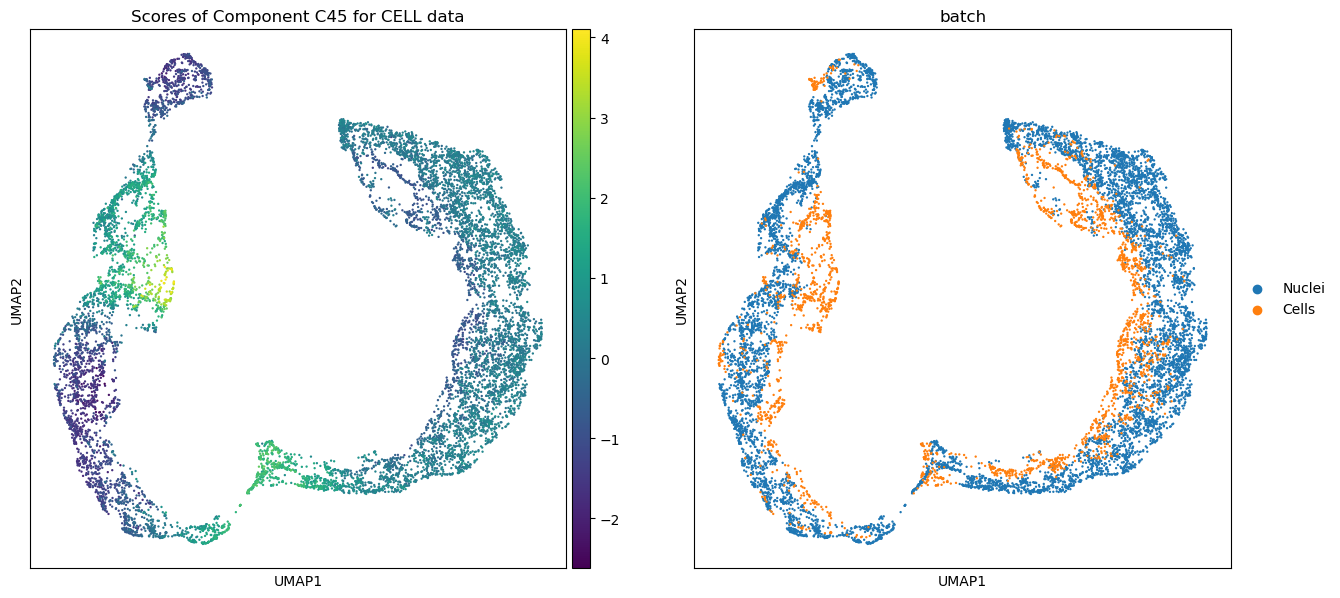

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

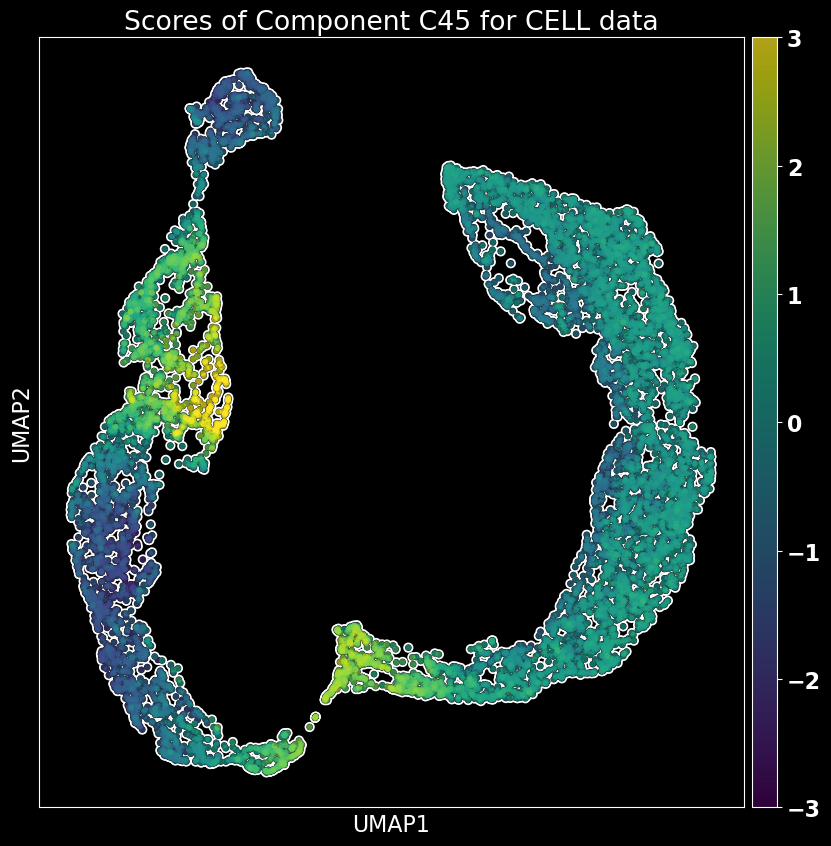

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

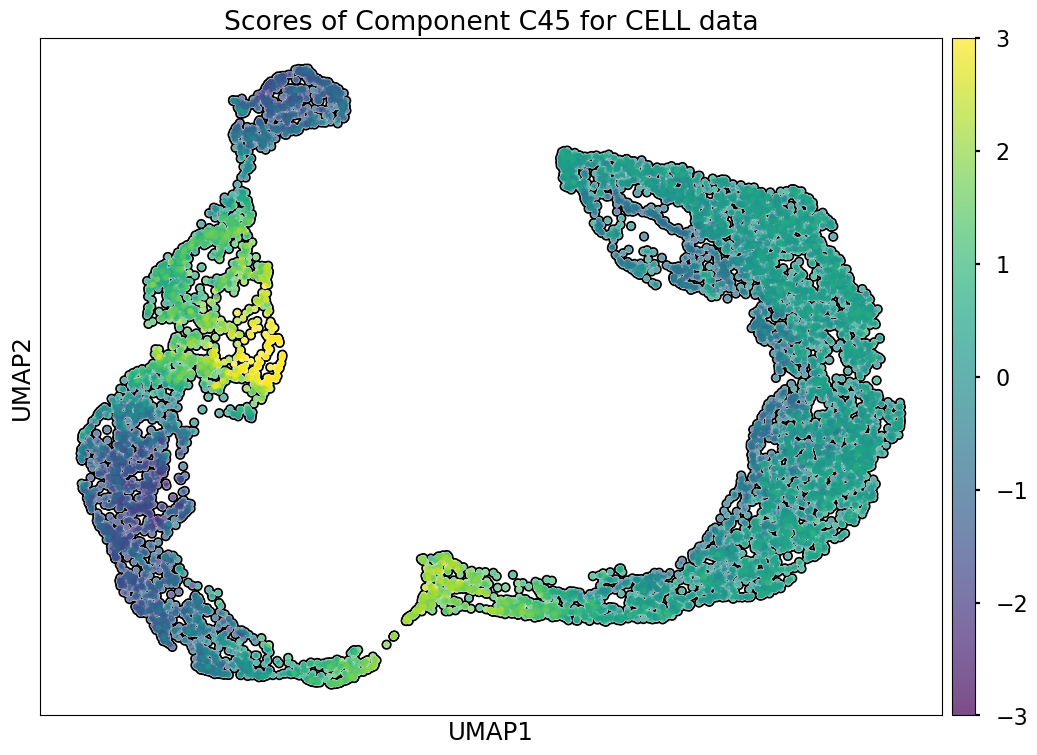

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

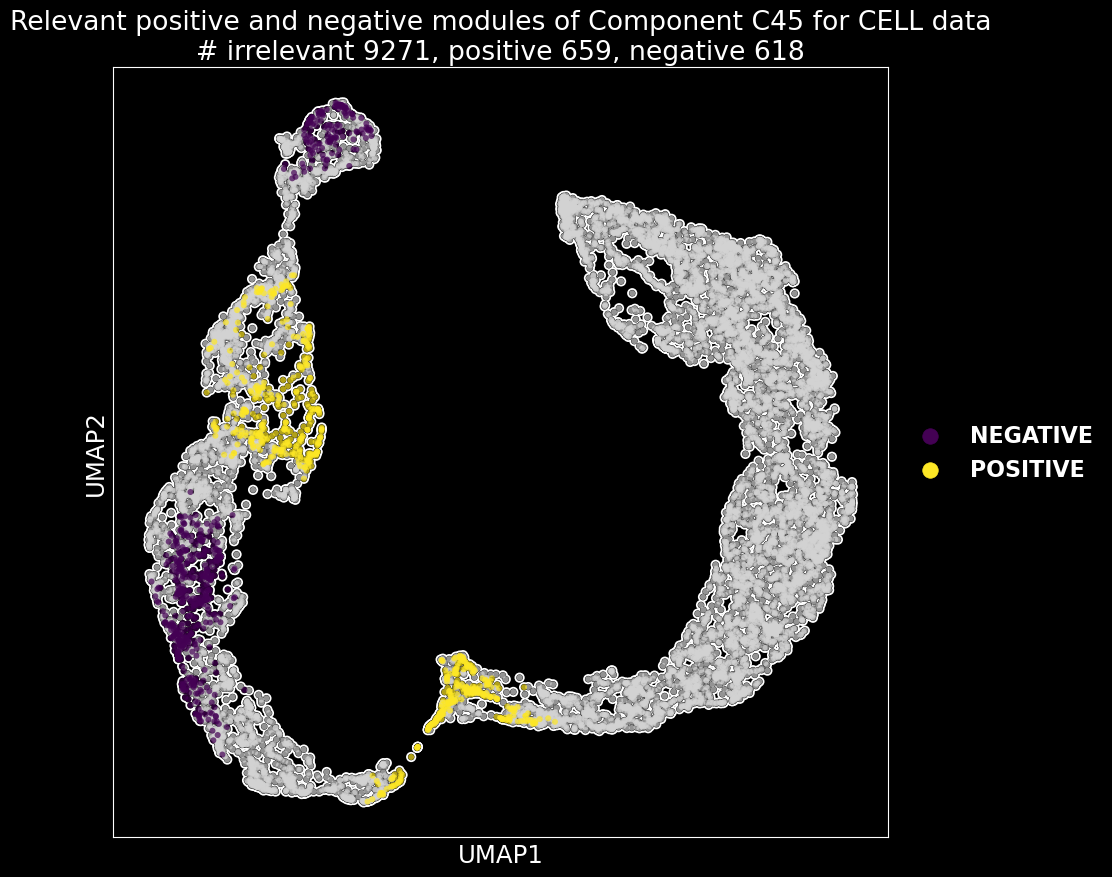

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

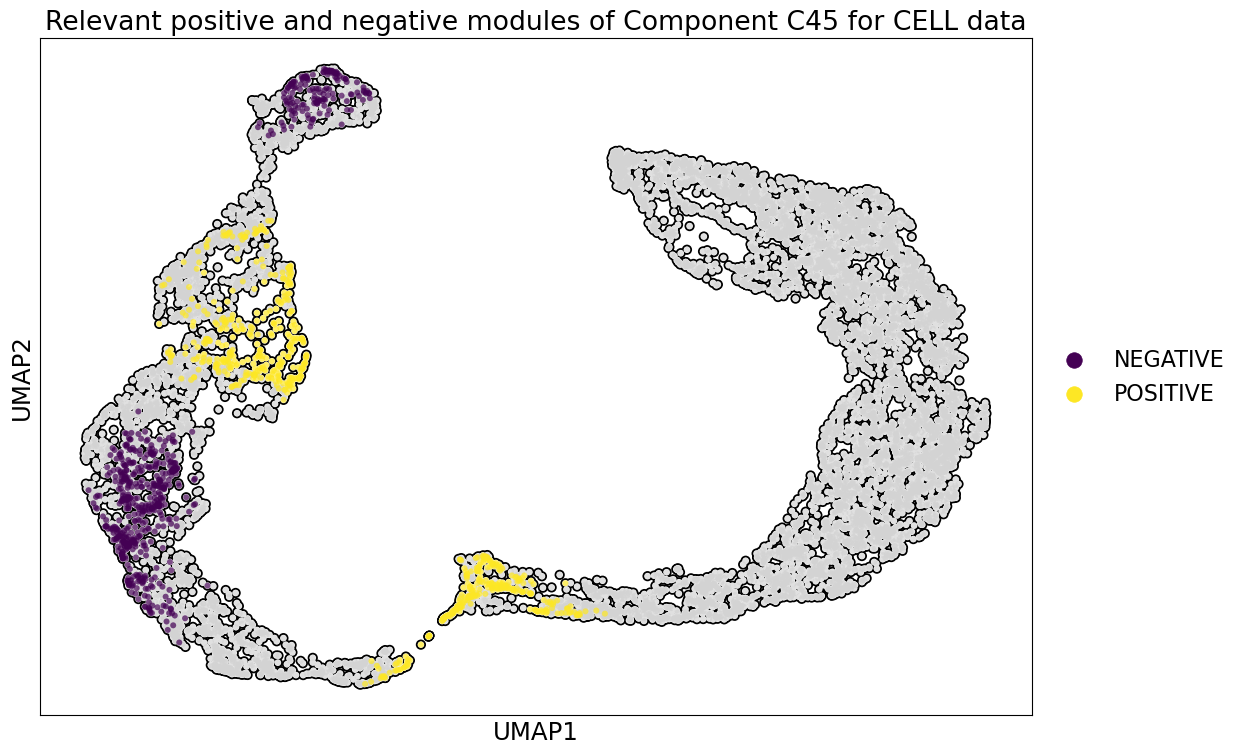

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.8247914108910894 var: 0.2434234563364664
Positive scores cells  - mean: 2.688437019607843 var: 0.5543054991274053


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.729671273344652 var: 0.18859692817412152
Negative scores cells  - mean: -2.2046082758620686 var: 0.1821916170346951


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=46.80917841001232, pvalue=0.0)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=1.0147641844984847, pvalue=0.31026873414682354)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C45', ylabel='Count'>

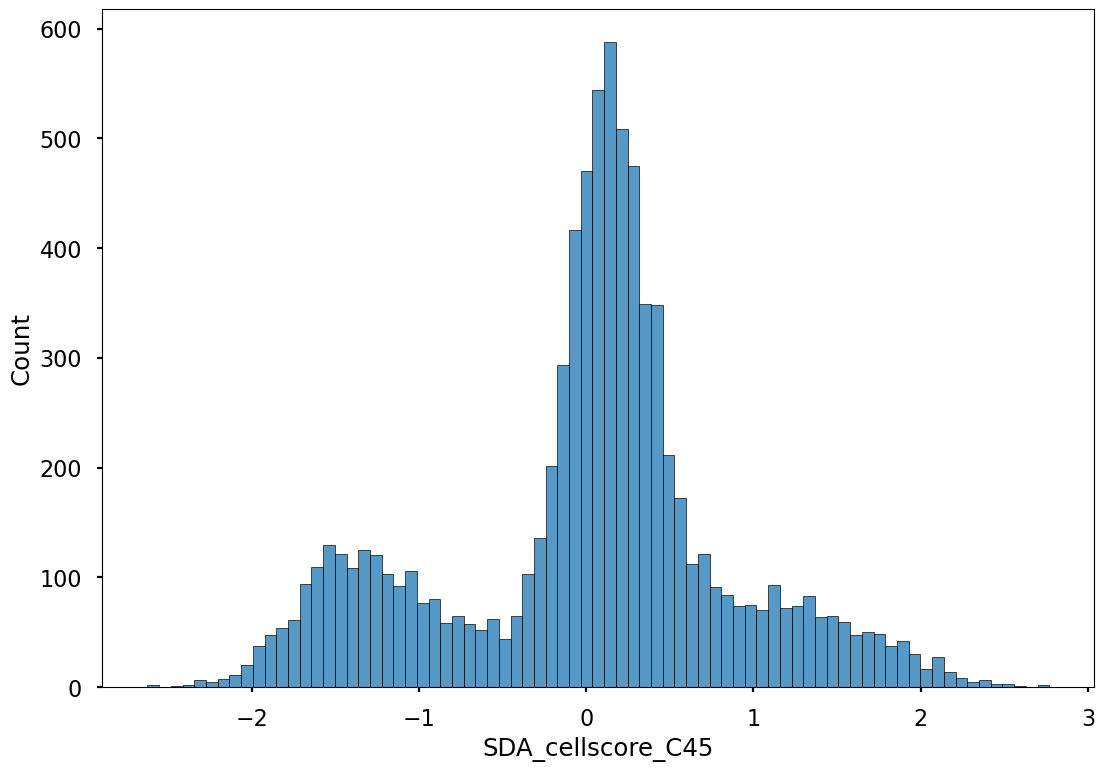

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C45', ylabel='Count'>

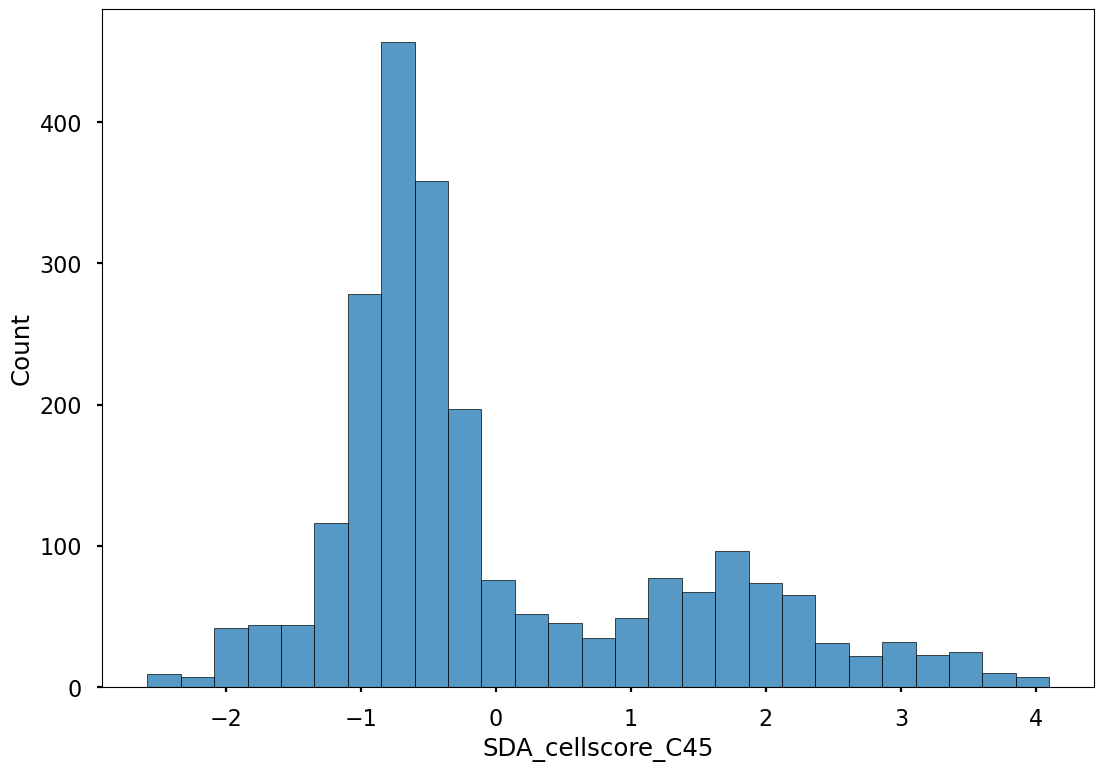

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C45: 1386


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

MRPL20
LOC469457
GNB1
MORN1
RER1
SLC2A5
SLC25A33
CTNNBIP1
LZIC
KIF1B
UBE2J2
SDF4
PLEKHM2
SPEN
MRTO4
DDOST
KDM1A
LUZP1
PITHD1
SRRM1
CLIC4
RSRP1
MACO1
CEP85
WASF2
FAM76A
RPA2
DNAJC8
TAF12
YTHDF2
EPB41
SRSF4
SNRNP40
ZCCHC17
PTP4A2
TXLNA
HDAC1
ZBTB8OS
S100PBP
ZMYM1
PSMB2
CLSPN
THRAP3
CDCA8
SF3A3
MACF1
RLF
CFAP57
ATP6V0B
RNF220
ARMH1
RPS8
ZSWIM5
TESK2
NASP
GPBP1L1
IPP
PIK3R3
LRRC41
LOC742376
STIL
ELAVL4
ECHDC2
HSPB11
TMEM59
TCEANC2
LOC107966822
LOC742772
USP1
ATG4C
EFCAB7
UBE2U
CACHD1
WDR78
SERBP1
DEPDC1
SLC44A5
MSH4
NEXN
BTBD8
MTF2
CCDC18
DR1
DNTTIP2
ARHGAP29
ABCD3
PRPF38B
WDR47
TAF13
KIAA1324
LAMTOR5
TMIGD3
SLC16A1
HIPK1
DENND2C
TCHH
ILF2
NUP210L
TPM3
UBAP2L
UBE2Q1
GON4L
SSR2
PFDN2
LOC104003547
ILDR2
DCAF6
TIPRL
NME7
BLZF1
DNM3
SUCO
LOC112204100
LAMC1
SMG7
ARPC5
RGL1
TRMT1L
SWT1
BRINP3
TROVE2
CRB1
CAMSAP2
IPO9
UBE2T
PPP1R12B
TMEM183A
ATP2B4
ZC3H11A
SRGAP2
LOC745816
SLC30A1
PPP2R5A
CENPF
GPATCH2
RRP15
MARK1
MIA3
DISP1
FBXO28
ARF1
EGLN1
TSNAX
DISC1
SIPA1L2
RBM34
ARID4B
WDR64
CNST
AHCTF1
LOC

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C45: 1391


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

LOC107974735
CAMTA1
RERE
CENPS
MTOR
VPS13D
KAZN
FHAD1
CAPZB
MINOS1
KIF17
EIF4G3
EPHB2
STMN1
CATSPER4
ZNF683
ARID1A
PHACTR4
PHC2
ZMYM4
AGO3
NDUFS5
SLFNL1
SCMH1
HIVEP3
CCDC30
ST3GAL3
AGBL4
FAF1
EPS15
SSBP3
USP24
DAB1
HOOK1
NFIA
PATJ
SLC35D1
LRRC7
ZRANB2
LOC104001211
NEGR1
ADGRL2
COL24A1
LOC100615600
LRRC8B
BRDT
GLMN
LOC100612616
PTBP2
SASS6
CDC14A
SORT1
GSTM4
CAPZA1
SYCP1
MAN1A2
FAM46C
SPAG17
LOC107967746
NOTCH2
LOC112208384
LOC104002001
RNF115
LOC738370
LOC749061
OTUD7B
VPS45
PLEKHO1
MRPS21
GOLPH3L
OAZ3
TDRD10
ARHGEF2
ARHGEF11
COPA
NOS1AP
PBX1
POU2F1
CCDC181
RABGAP1L
ABL2
AXDND1
TDRD5
CACNA1E
SHCBP1L
LOC112206075
CDC73
KDM5B
LOC107969752
MAPKAPK2
CD46
SYT14
RCOR3
FAM71A
SPATA17
LYPLAL1
DNAH14
CDC42BPA
RAB4A
ERO1B
MTR
RYR2
LOC104004798
CHRM3
RGS7
CEP170
AKT3
CATSPERE
DESI2
EFCAB2
KIF26B
SMYD3
SCCPDH
ZNF670
SH3YL1
LOC112208151
SNTG2
MYT1L
RNF144A
MBOAT2
ASAP2
NOL10
LOC104004883
NBAS
RAD51AP2
LAPTM4A
LOC107973155
LOC104004902
NCOA1
DTNB
DRC1
PRR30
PPM1G
IFT172
FNDC4
BABAM2
CLIP4
YPEL5
MEMO

#### Cells scores by cluster

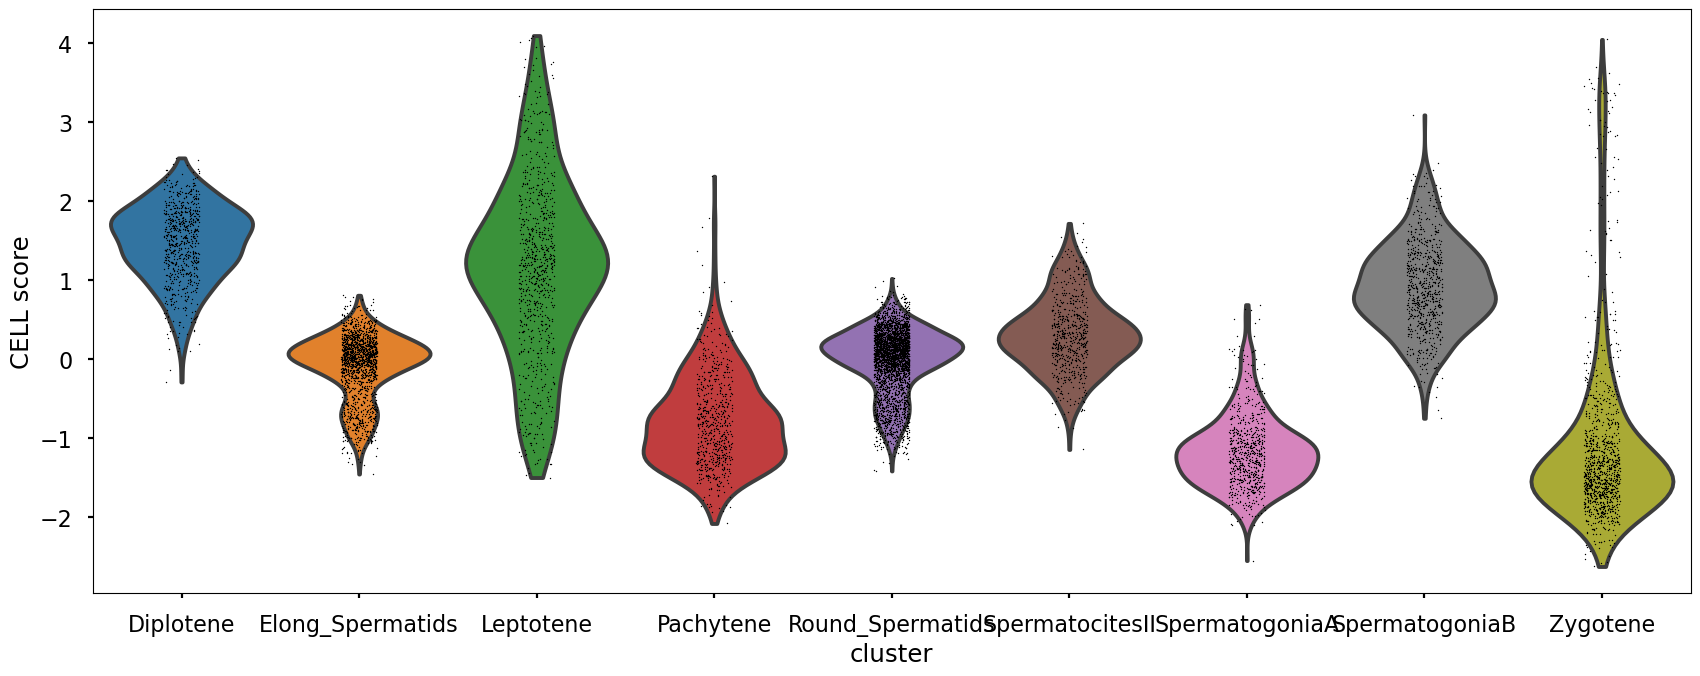

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

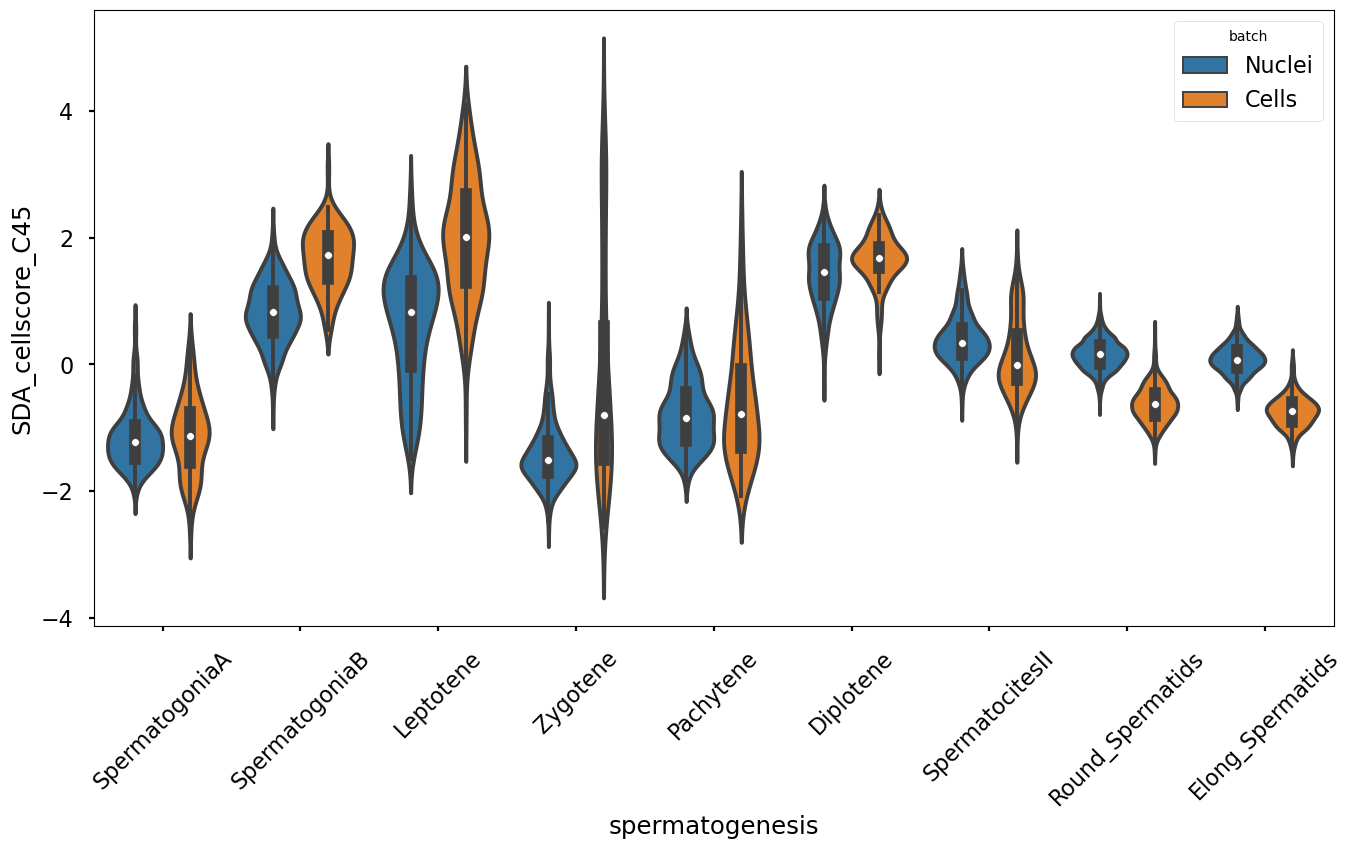

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C45')

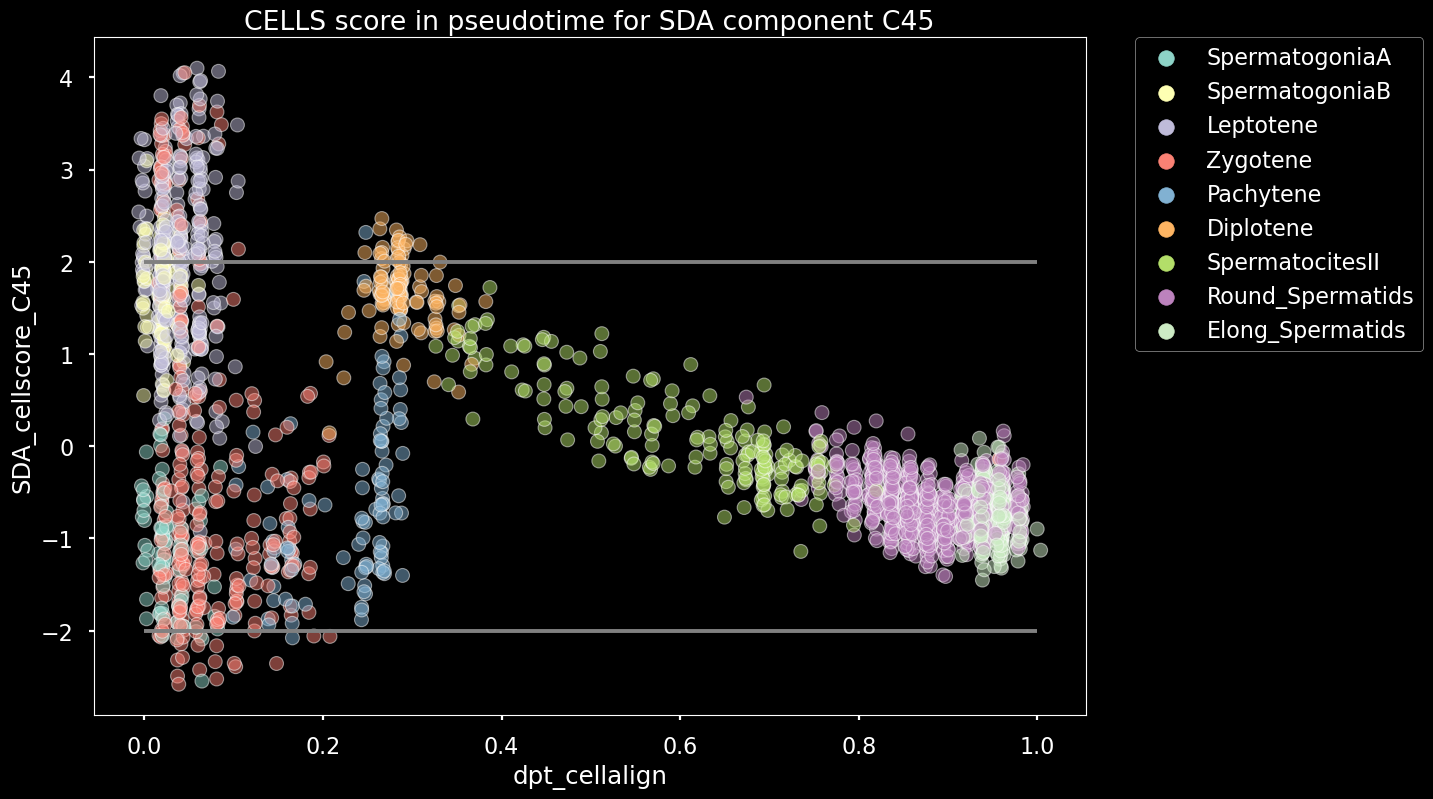

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C45')

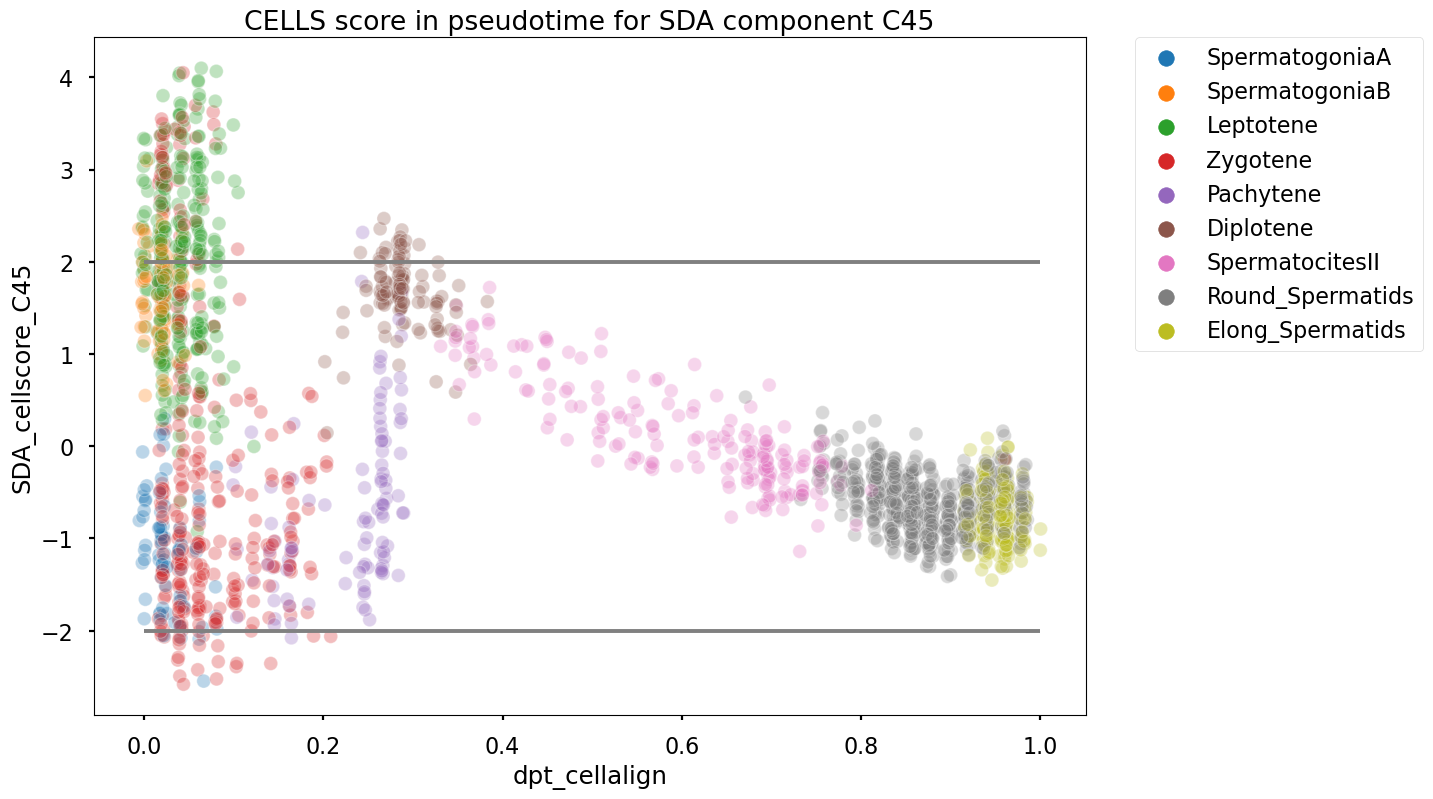

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C45')

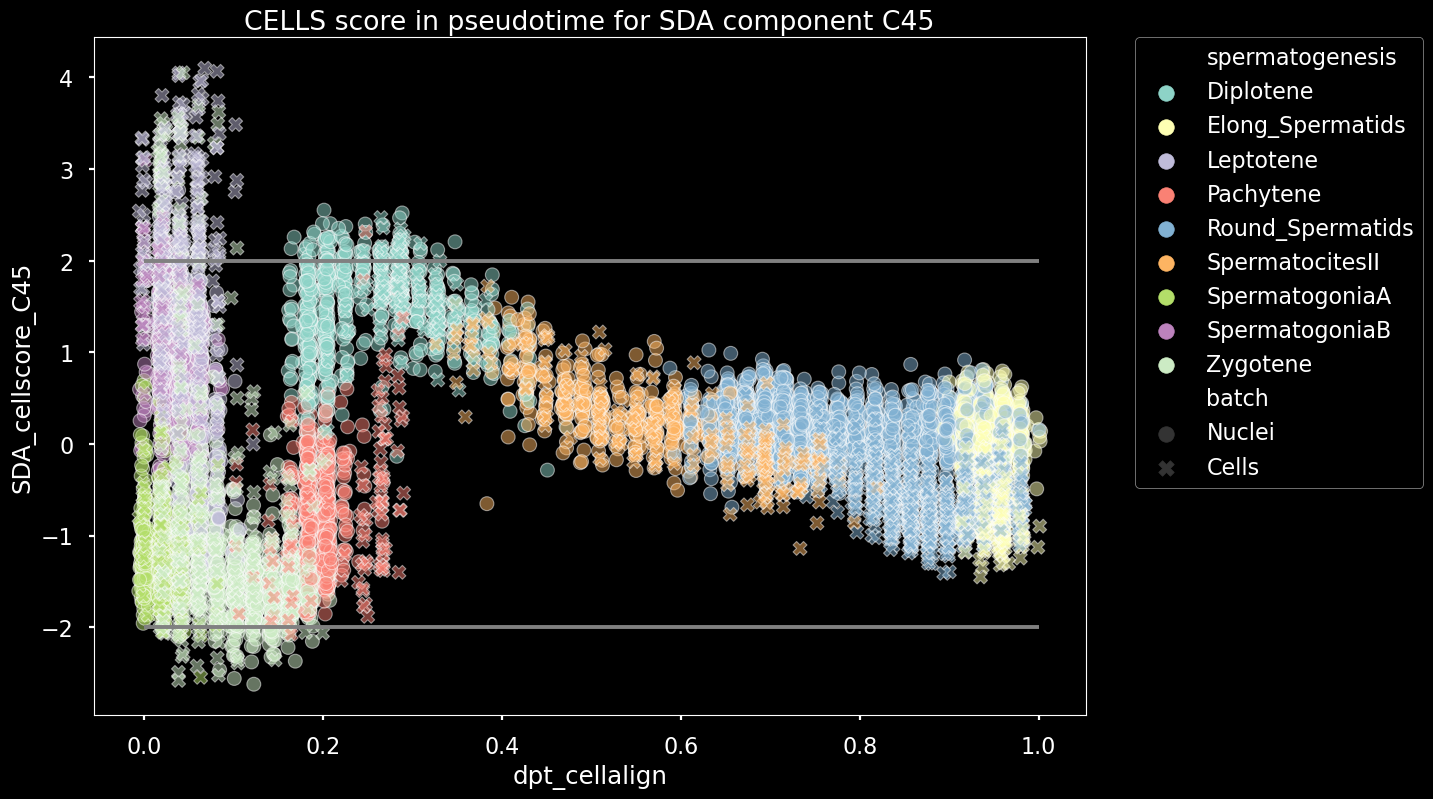

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C45')

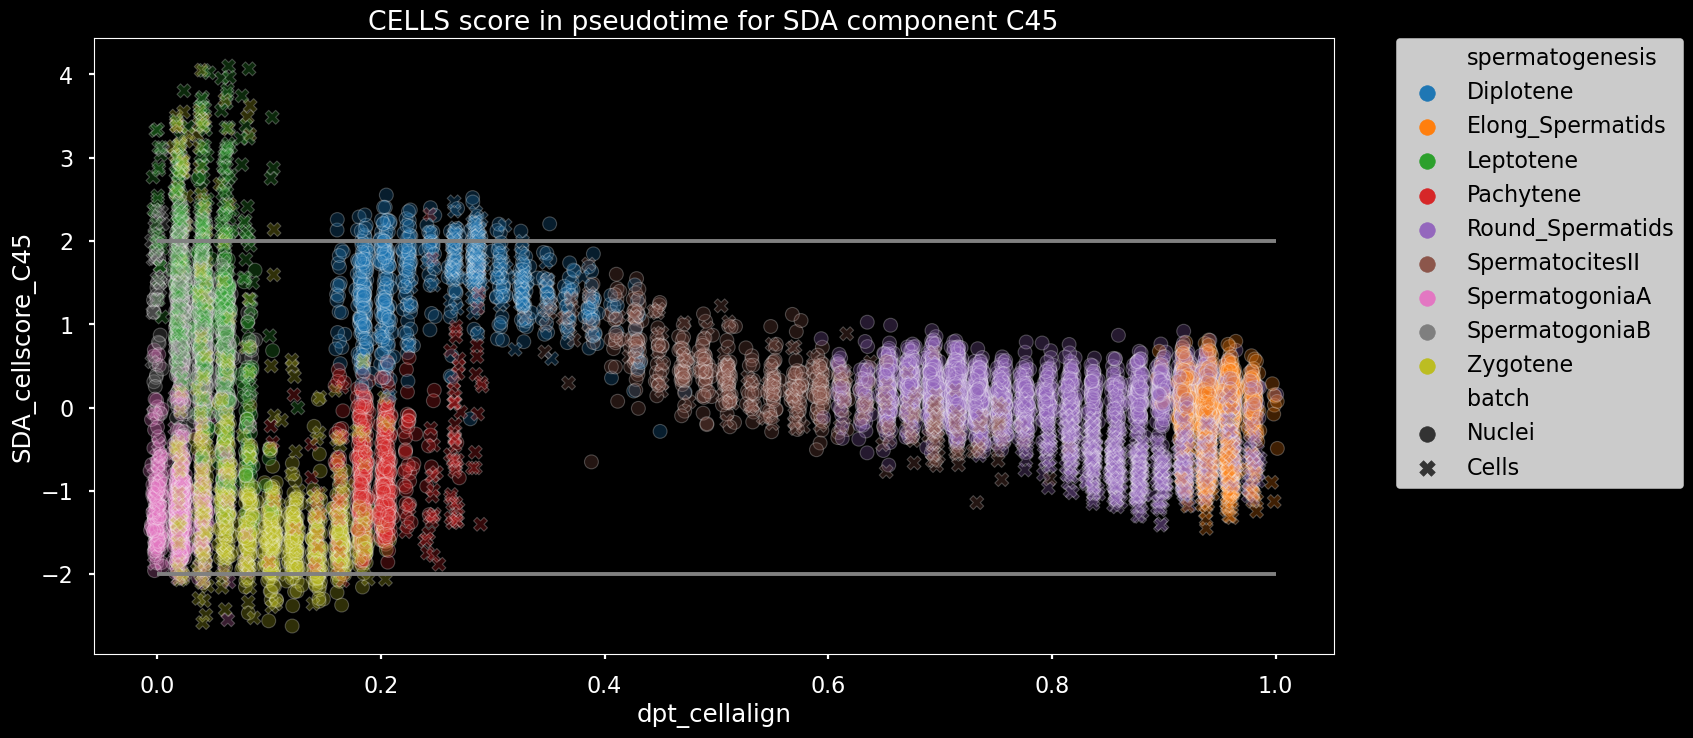

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,35/171,5.649095e-09,1.502659e-06,0,0,3.519887,66.848890,RPN2;UBXN2A;UBE2D3;RPN1;SEL1L2;UBE2J2;ATXN3;OS...
266,GO_Cellular_Component_2023,Nucleus (GO:0005634),446/4487,2.915732e-18,1.046748e-15,0,0,1.711067,69.086760,NEXMIF;GPATCH2;TESK2;PHAX;SMC5;ADARB1;SMC6;RBP...
267,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,496/5175,1.716819e-17,3.081690e-15,0,0,1.659761,64.072546,VPS29;CHIC2;SLC4A1AP;NEXMIF;GPATCH2;TESK2;PHAX...
268,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,156/1195,4.593366e-15,5.496728e-13,0,0,2.145356,70.827118,ARID4A;ADARB1;RBPJ;SMC3;MKI67;ACTB;CDC14B;RPS1...
269,GO_Cellular_Component_2023,Chromosome (GO:0005694),38/164,2.759505e-11,2.476656e-09,0,0,4.136310,100.567699,TOP2A;HMGB2;NCAPG;DDX21;NOL8;SMC5;SMC6;BRCA1;H...
270,GO_Cellular_Component_2023,Spindle (GO:0005819),41/210,1.270102e-09,9.119334e-08,0,0,3.327006,68.150943,EPB41;CLTC;HNF4G;KIF11;HMMR;CDC14B;AURKA;GOLGA...
271,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),32/143,2.531912e-09,1.514928e-07,0,0,3.939585,77.981293,EPB41;CLTC;HNF4G;KIF11;CDC14B;AURKA;GOLGA2;NUS...
272,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),96/780,2.384284e-08,1.200486e-06,0,0,1.950768,34.239462,TOP2A;FEN1;HMGB2;ADARB1;RBPJ;MKI67;PHF8;SMG6;C...
273,GO_Cellular_Component_2023,Nucleolus (GO:0005730),95/771,2.675178e-08,1.200486e-06,0,0,1.952651,34.047726,TOP2A;FEN1;HMGB2;ADARB1;RBPJ;MKI67;PHF8;SMG6;C...
274,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),55/387,2.927288e-07,1.167663e-05,0,0,2.275465,34.232147,YWHAE;ARF1;CD81;RPLP1;CLTC;GDI2;ARPC5L;RPL10A;...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,35/171,1.502659e-06,3.519887,66.848890,RPN2;UBXN2A;UBE2D3;RPN1;SEL1L2;UBE2J2;ATXN3;OS...,45P,Yes,659
266,GO_Cellular_Component_2023,Nucleus (GO:0005634),446/4487,1.046748e-15,1.711067,69.086760,NEXMIF;GPATCH2;TESK2;PHAX;SMC5;ADARB1;SMC6;RBP...,45P,Yes,659
267,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,496/5175,3.081690e-15,1.659761,64.072546,VPS29;CHIC2;SLC4A1AP;NEXMIF;GPATCH2;TESK2;PHAX...,45P,Yes,659
268,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,156/1195,5.496728e-13,2.145356,70.827118,ARID4A;ADARB1;RBPJ;SMC3;MKI67;ACTB;CDC14B;RPS1...,45P,Yes,659
269,GO_Cellular_Component_2023,Chromosome (GO:0005694),38/164,2.476656e-09,4.136310,100.567699,TOP2A;HMGB2;NCAPG;DDX21;NOL8;SMC5;SMC6;BRCA1;H...,45P,Yes,659
270,GO_Cellular_Component_2023,Spindle (GO:0005819),41/210,9.119334e-08,3.327006,68.150943,EPB41;CLTC;HNF4G;KIF11;HMMR;CDC14B;AURKA;GOLGA...,45P,Yes,659
271,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),32/143,1.514928e-07,3.939585,77.981293,EPB41;CLTC;HNF4G;KIF11;CDC14B;AURKA;GOLGA2;NUS...,45P,Yes,659
272,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),96/780,1.200486e-06,1.950768,34.239462,TOP2A;FEN1;HMGB2;ADARB1;RBPJ;MKI67;PHF8;SMG6;C...,45P,Yes,659
273,GO_Cellular_Component_2023,Nucleolus (GO:0005730),95/771,1.200486e-06,1.952651,34.047726,TOP2A;FEN1;HMGB2;ADARB1;RBPJ;MKI67;PHF8;SMG6;C...,45P,Yes,659
274,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),55/387,1.167663e-05,2.275465,34.232147,YWHAE;ARF1;CD81;RPLP1;CLTC;GDI2;ARPC5L;RPL10A;...,45P,Yes,659


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
603,Human_Gene_Atlas,PrefrontalCortex,75/521,1.357395e-09,9.617477e-08,0,0,2.320909,47.387619,RERE;CHRM3;CNTNAP2;RYR2;TRIO;CTNND2;CELF2;PTPR...
604,Human_Gene_Atlas,TestisIntersitial,79/568,2.466020e-09,9.617477e-08,0,0,2.231221,44.224274,PIWIL1;SPAG17;KDM5B;SYCP1;CEP164;ULK4;CETN3;EF...
605,Human_Gene_Atlas,pineal day,77/694,3.104805e-05,8.072493e-04,0,0,1.708794,17.737235,SPAG16;ROBO2;FHOD3;ARL6IP1;CHD9;PDCD6;CEP164;P...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
603,Human_Gene_Atlas,PrefrontalCortex,75/521,9.617477e-08,2.320909,47.387619,RERE;CHRM3;CNTNAP2;RYR2;TRIO;CTNND2;CELF2;PTPR...,45N,No,618
604,Human_Gene_Atlas,TestisIntersitial,79/568,9.617477e-08,2.231221,44.224274,PIWIL1;SPAG17;KDM5B;SYCP1;CEP164;ULK4;CETN3;EF...,45N,No,618
605,Human_Gene_Atlas,pineal day,77/694,8.072493e-04,1.708794,17.737235,SPAG16;ROBO2;FHOD3;ARL6IP1;CHD9;PDCD6;CEP164;P...,45N,No,618


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

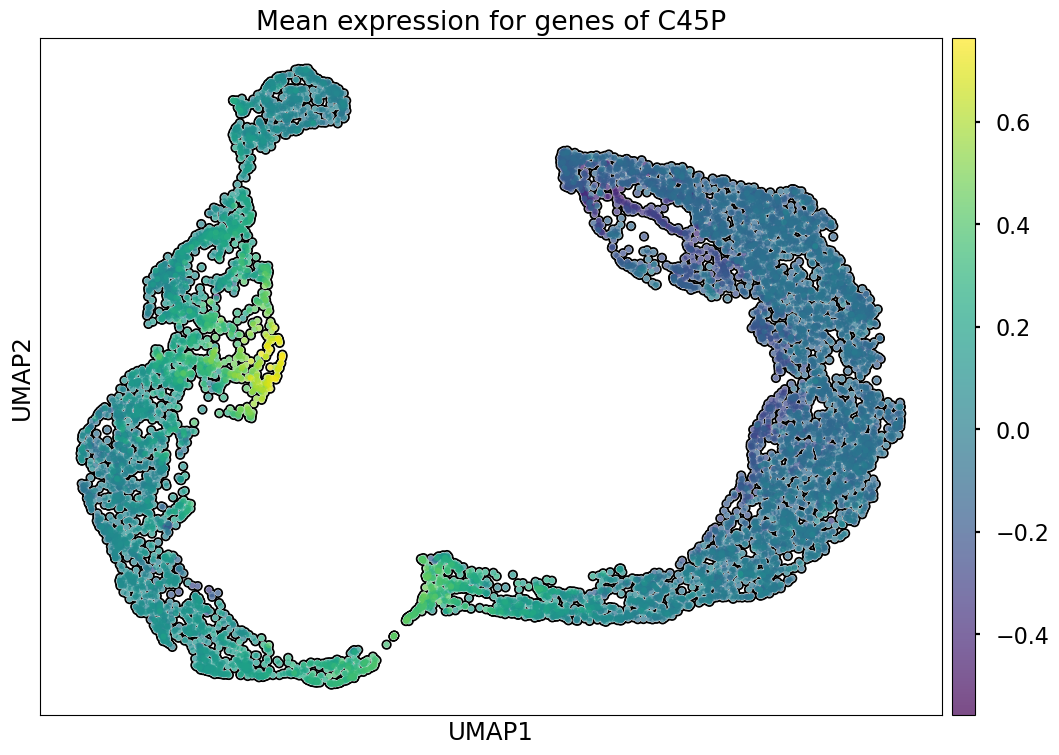

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

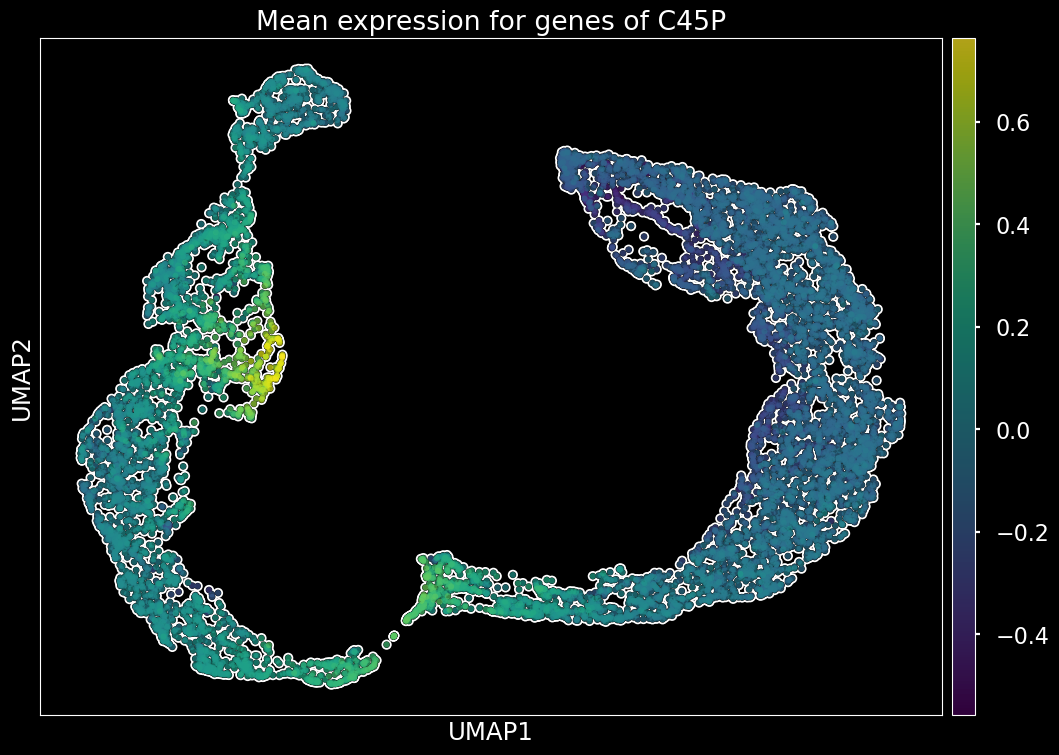

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

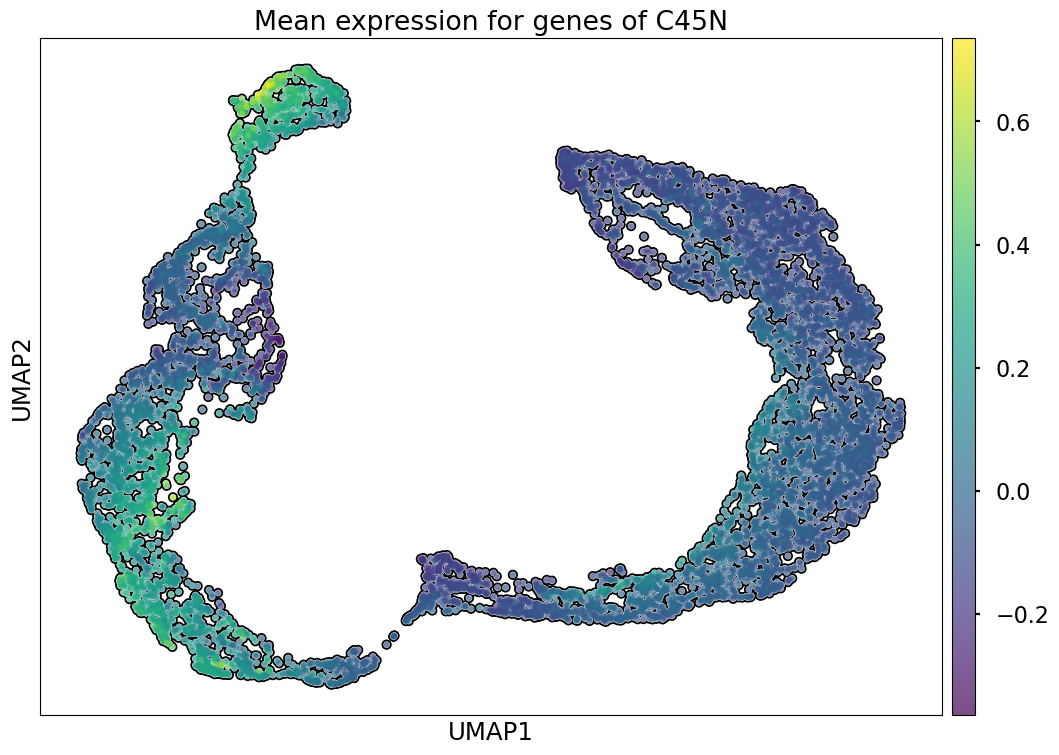

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

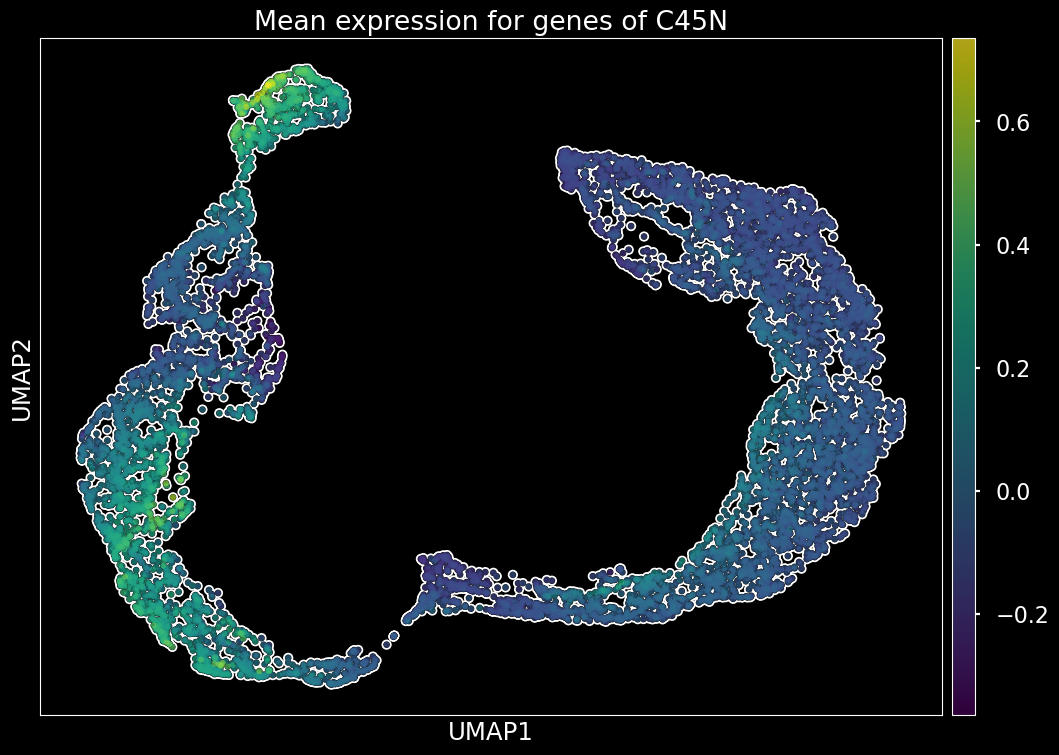

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)